# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 4 — Time-Series Data Preparation for Forecasting

**Module:** Forecasting Models — data prep stage (Phase 3)

Uses `data/processed/timeseries_daily.csv` from Day 2. This notebook:
1. Visualizes the raw daily revenue series
2. Runs stationarity tests (ADF, KPSS)
3. Performs seasonal decomposition (trend / seasonality / residual)
4. Applies differencing where needed and re-tests
5. Prepares the final `ds`/`y` frame that Prophet (Day 5) and the LSTM windows (Day 6) will consume

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"

daily = pd.read_csv(f"{PROCESSED_DIR}/timeseries_daily.csv", parse_dates=["Date"])
daily = daily.set_index("Date").asfreq("D")
print(f"Series length: {len(daily)} days ({daily.index.min().date()} to {daily.index.max().date()})")
daily[["Revenue"]].head()

Series length: 730 days (2023-01-02 to 2024-12-31)


,Revenue
Date,
2023-01-02,2005.74
2023-01-03,2101.51
2023-01-04,3168.73
2023-01-05,322.53
2023-01-06,7303.83


## 1. Raw Series Visualization

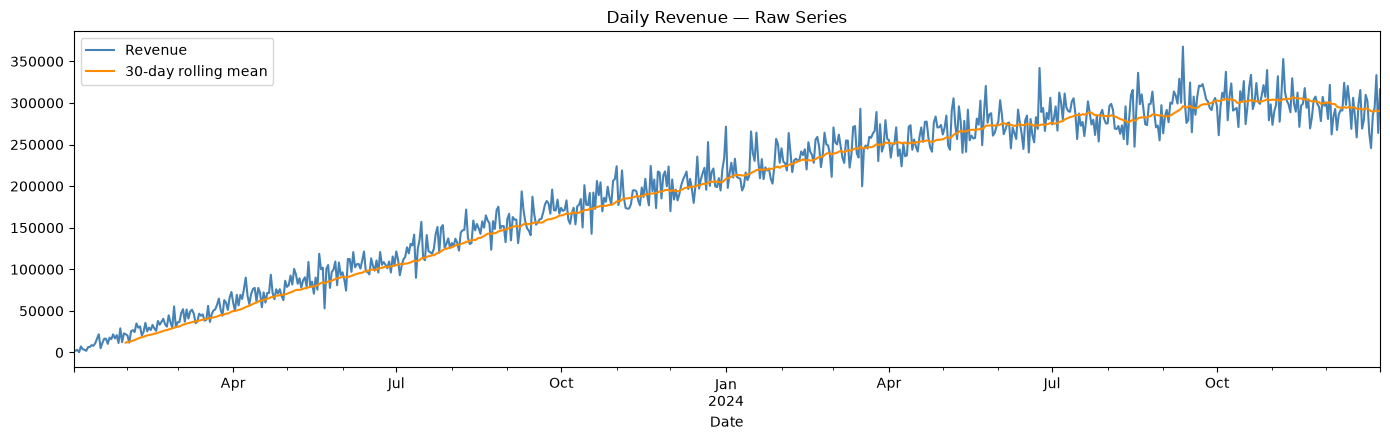

In [2]:
fig, ax = plt.subplots(figsize=(14, 4.5))
daily["Revenue"].plot(ax=ax, color="steelblue")
daily["Revenue"].rolling(30).mean().plot(ax=ax, color="darkorange", label="30-day rolling mean")
ax.set_title("Daily Revenue — Raw Series")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day4_raw_series.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Stationarity Tests

- **ADF (Augmented Dickey-Fuller)** — null hypothesis: series has a unit root (non-stationary). A low p-value (< 0.05) rejects the null → series is stationary.
- **KPSS** — null hypothesis is the opposite: series *is* stationary. A low p-value here suggests non-stationarity.

Running both together avoids relying on a single test's assumptions.

In [3]:
def run_stationarity_tests(series, label):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series)
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")

    print(f"--- {label} ---")
    print(f"ADF  : stat={adf_stat:.3f}, p-value={adf_p:.4f} "
          f"-> {'STATIONARY' if adf_p < 0.05 else 'NON-STATIONARY'}")
    print(f"KPSS : stat={kpss_stat:.3f}, p-value={kpss_p:.4f} "
          f"-> {'STATIONARY' if kpss_p >= 0.05 else 'NON-STATIONARY'}")
    print()
    return {"adf_p": adf_p, "kpss_p": kpss_p}

raw_result = run_stationarity_tests(daily["Revenue"], "Raw Revenue")

--- Raw Revenue ---
ADF  : stat=-3.153, p-value=0.0228 -> STATIONARY
KPSS : stat=4.012, p-value=0.0100 -> NON-STATIONARY



## 3. Seasonal Decomposition

Additive decomposition with a 7-day period (weekly seasonality is the dominant retail pattern).

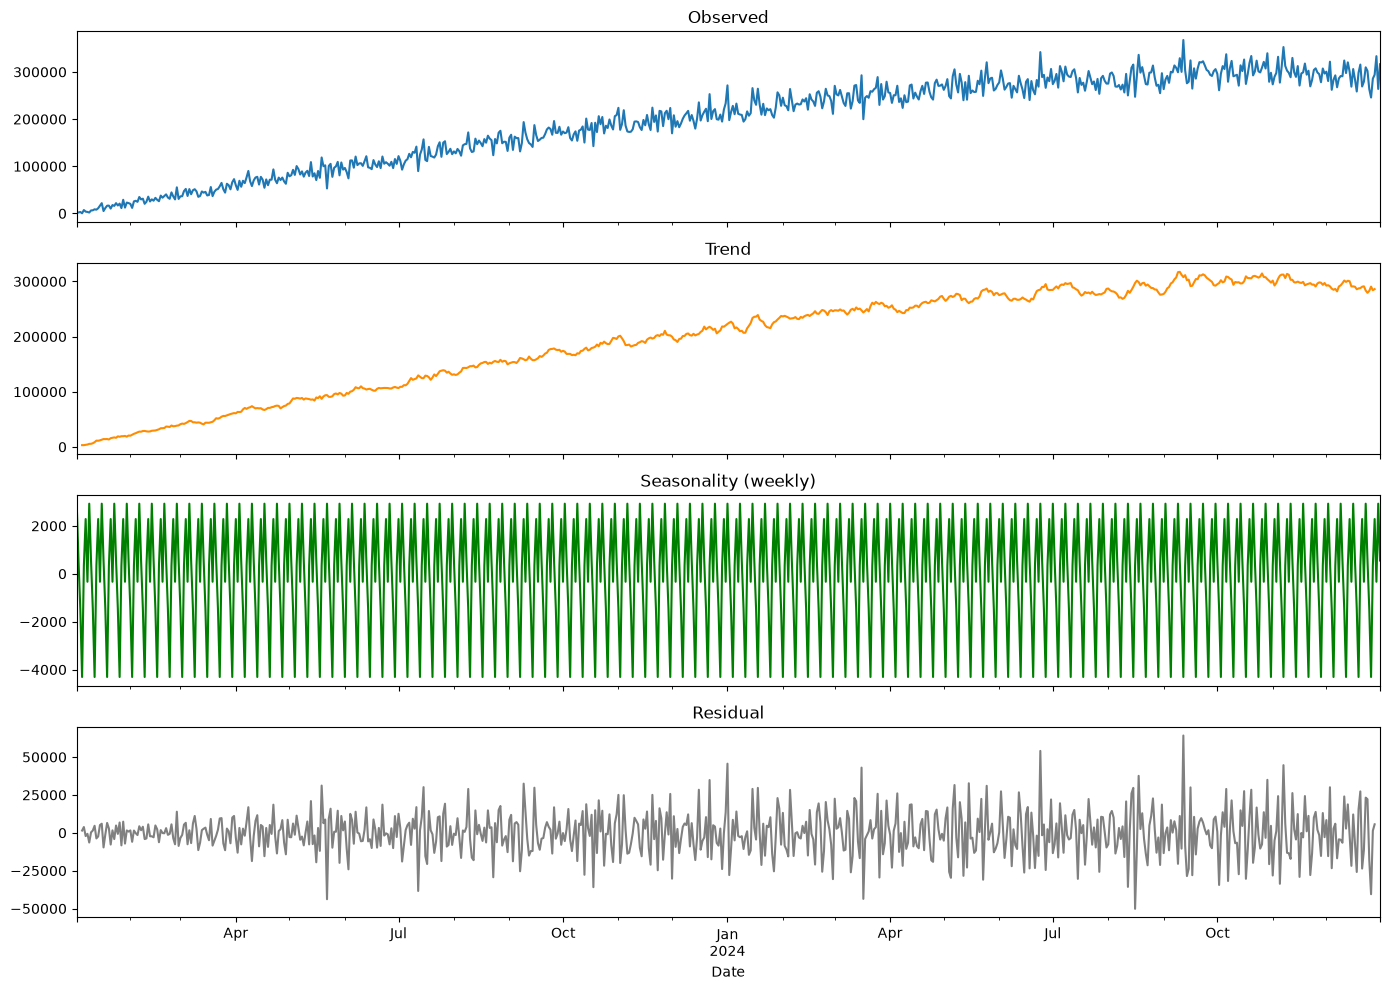

In [4]:
decomposition = seasonal_decompose(daily["Revenue"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend", color="darkorange")
decomposition.seasonal.plot(ax=axes[2], title="Seasonality (weekly)", color="green")
decomposition.resid.plot(ax=axes[3], title="Residual", color="gray")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day4_decomposition.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Differencing (if needed)

If the ADF/KPSS tests above disagree or both indicate non-stationarity, apply first-order differencing and re-test. Prophet handles trend/seasonality internally so this step is mainly informative + useful for the ARIMA/SARIMA reference approach; the LSTM notebook will use its own scaling/windowing instead of differencing.

--- 1st-Order Differenced Revenue ---
ADF  : stat=-12.170, p-value=0.0000 -> STATIONARY
KPSS : stat=0.290, p-value=0.1000 -> STATIONARY



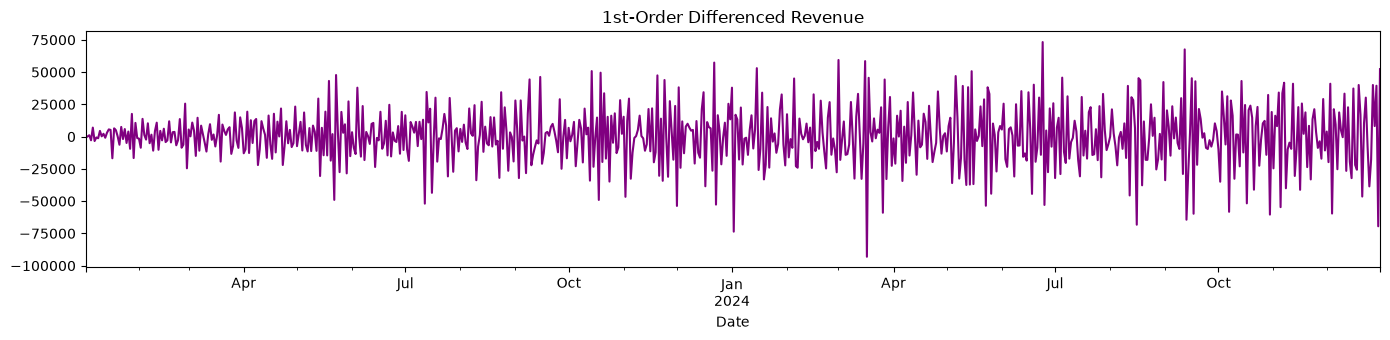

In [5]:
needs_differencing = not (raw_result["adf_p"] < 0.05 and raw_result["kpss_p"] >= 0.05)

if needs_differencing:
    daily["Revenue_diff1"] = daily["Revenue"].diff()
    diff_result = run_stationarity_tests(daily["Revenue_diff1"], "1st-Order Differenced Revenue")

    fig, ax = plt.subplots(figsize=(14, 3.5))
    daily["Revenue_diff1"].plot(ax=ax, color="purple")
    ax.set_title("1st-Order Differenced Revenue")
    plt.tight_layout()
    plt.savefig(f"{REPORTS_DIR}/day4_differenced_series.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Series already stationary by both tests — skipping differencing.")

## 5. Autocorrelation Check

ACF/PACF plots on the (possibly differenced) series — informs the `p`/`q` order for the ARIMA/SARIMA reference notebook and confirms the weekly seasonal lag (lag 7) visible in the decomposition above.

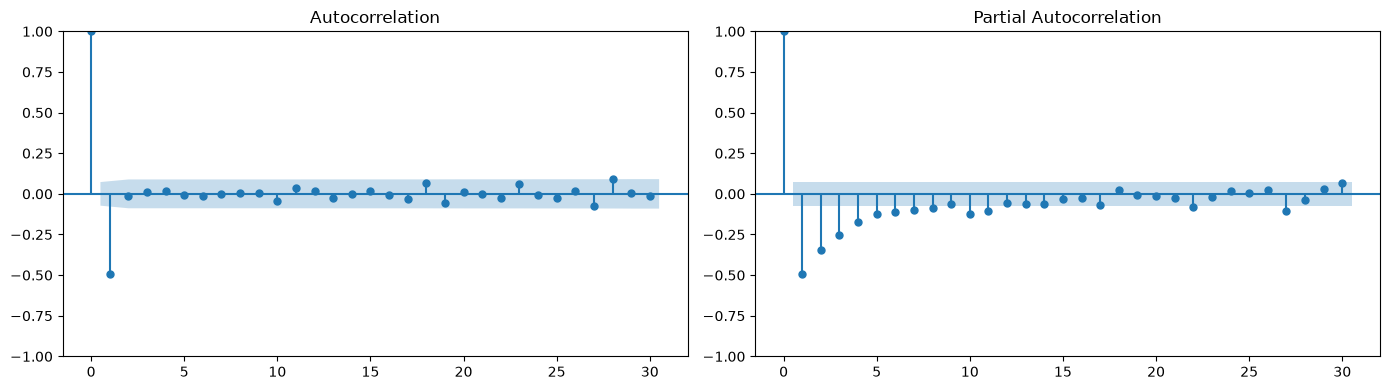

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series_for_acf = daily["Revenue_diff1"].dropna() if needs_differencing else daily["Revenue"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_for_acf, lags=30, ax=axes[0])
plot_pacf(series_for_acf, lags=30, ax=axes[1])
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day4_acf_pacf.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Prepare Prophet-Ready Frame

Prophet requires exactly two columns: `ds` (datestamp) and `y` (value). Also persist the full feature-rich frame (with lag/rolling columns from Day 2) for the LSTM notebook, which can use those as additional input channels.

In [7]:
prophet_df = daily.reset_index()[["Date", "Revenue"]].rename(columns={"Date": "ds", "Revenue": "y"})
prophet_df.to_csv(f"{PROCESSED_DIR}/prophet_ready.csv", index=False)

daily.reset_index().to_csv(f"{PROCESSED_DIR}/timeseries_features_full.csv", index=False)

print(f"Prophet-ready frame: {prophet_df.shape}")
prophet_df.tail()

Prophet-ready frame: (730, 2)


,ds,y
725,2024-12-27,285811.81
726,2024-12-28,294000.01
727,2024-12-29,333438.46
728,2024-12-30,263961.77
729,2024-12-31,316274.24


## 7. Day 4 Checkpoint Summary

**Outputs saved:**
- `data/processed/prophet_ready.csv` — `ds`/`y` frame for Day 5 Prophet baseline
- `data/processed/timeseries_features_full.csv` — full feature set for Day 6 LSTM
- `reports/day4_raw_series.png`, `day4_decomposition.png`, `day4_acf_pacf.png` (+ `day4_differenced_series.png` if differencing was applied)

**Findings:**
- ADF/KPSS results printed above determine whether the raw series needed differencing
- Weekly (7-day) seasonality confirmed via decomposition and ACF

**Next module:** `05_prophet_baseline` — fit a baseline Prophet model with weekly/yearly seasonality on `prophet_ready.csv`.